# AlpsML · Modelos UV de ALPs con XGBoost + SHAP + MCMC

Surrogate ML del χ² de un **modelo UV no-universal Peccei–Quinn** (`alpaca`),
explorando 6 acoples PQ en transiciones raras de mesones K y B con un axion-like
particle de masa fija $m_a = 2$ GeV.

### Pipeline

1. **Dataset χ²**: 15 000 puntos en Latin Hypercube 6D sobre $(\log f_a, p^{qL}, p^{lL}, p^{uR}, p^{dR}, p^{eR})$, `chi2` de las 5 transiciones combinadas vía `alpaca`. Paralelo con `multiprocessing.Pool` y backup cada 100 puntos. Target sigmoide centrado en $\chi^2 = 10$.
2. **XGBoost**: regresor del target ponderado (puntos excluidos pesan ×5). Búsqueda Optuna (100 trials) + entrenamiento final con early stopping. Profundidad 2–6, regularización $\alpha,\lambda \in [0.1, 10]$.
3. **SHAP**: `Permutation Explainer` (sin meterse con la lectura del JSON XGBoost). Bee swarm, bar, waterfall y dependence plots.
4. **MCMC**: 50 walkers × 5 000 pasos con `emcee` sobre el surrogate; `corner` plot del posterior con burn-in 1 000 y thin 15.

### Cachés

Las dos etapas pesadas (generación del dataset y entrenamiento) están **gateadas**:
solo corren si el archivo no existe **o** si pones a `True` el flag correspondiente
en el bloque de Setup (`FORCE_REGENERATE`, `FORCE_RETRAIN`).


## Índice

| §   | Sección                                  | Caché                              | Coste aprox. |
|-----|------------------------------------------|------------------------------------|--------------|
| [Setup](#setup)        | Imports, paths, flags             | —                                  | <1 s |
| [§1](#sec-1)           | Generación del dataset χ²         | `outputs/datasets/dataset_alps_uv.csv` | minutos (15 000 evals × `alpaca`) |
| [§2](#sec-2)           | Inspección del dataset            | —                                  | <1 s |
| [§3](#sec-3)           | Entrenamiento XGBoost (Optuna)    | `outputs/models/modelo_alps_uv.json` | ~5 min (100 trials × 1000 rondas) |
| [§4](#sec-4)           | Interpretabilidad SHAP            | —                                  | ~30 s |
| [§5](#sec-5)           | Posterior MCMC + corner plot      | `outputs/datasets/posterior_samples_uv.csv` | ~1 min (50 walkers × 5 000 pasos) |


## <a id="setup"></a>Setup (ejecutar primero)

Define paths via `pathlib`, crea los directorios de salida si no existen, y fija
los flags `FORCE_REGENERATE` / `FORCE_RETRAIN`. También limita BLAS a 1 thread por
proceso (la generación paralelizará a mano con `multiprocessing.Pool`).


In [ ]:
import os

# BLAS: 1 thread por proceso (la generación reparte por mp.Pool)
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"

from pathlib import Path

# --- Paths ---
ROOT = Path.cwd().parent
OUTPUTS = ROOT / "outputs"
DATASETS_DIR = OUTPUTS / "datasets"
MODELS_DIR   = OUTPUTS / "models"
FIGURES_DIR  = OUTPUTS / "figures"
for d in (DATASETS_DIR, MODELS_DIR, FIGURES_DIR):
    d.mkdir(parents=True, exist_ok=True)

DATASET_CSV     = DATASETS_DIR / "dataset_alps_uv.csv"
DATASET_BACKUP  = DATASETS_DIR / "backup_dataset_alps_uv.csv"
MODEL_PATH      = MODELS_DIR   / "modelo_alps_uv.json"
BEST_PARAMS     = MODELS_DIR   / "best_params_uv.json"
POSTERIOR_CSV   = DATASETS_DIR / "posterior_samples_uv.csv"
CORNER_PNG      = FIGURES_DIR  / "corner_plot_uv.png"

# --- Flags de regeneración ---
# Por defecto las etapas pesadas usan caché. Pon a True para forzar.
FORCE_REGENERATE = False   # §1 — regenera el dataset χ² (varios minutos)
FORCE_RETRAIN    = False   # §3 — reentrena XGBoost desde cero (~5 min)

print("Setup OK")
print(f"  ROOT       = {ROOT}")
print(f"  dataset    = {DATASET_CSV} ({'exists' if DATASET_CSV.exists() else 'missing'})")
print(f"  model      = {MODEL_PATH}  ({'exists' if MODEL_PATH.exists() else 'missing'})")
print(f"  posterior  = {POSTERIOR_CSV} ({'exists' if POSTERIOR_CSV.exists() else 'missing'})")
print(f"  FORCE_REGENERATE = {FORCE_REGENERATE}    FORCE_RETRAIN = {FORCE_RETRAIN}")


## <a id="sec-1"></a>§1. Generación del dataset χ²

Latin Hypercube en 6 dimensiones sobre $(\log f_a, p_{qL}, p_{lL}, p_{uR}, p_{dR}, p_{eR})$
con `scipy.stats.qmc.LatinHypercube`. Para cada punto se construye un `PQChargedModel` no
universal (carga PQ solo en la 3ª familia de quarks/leptones izquierdos) y se calcula
$\chi^2$ combinado de las 5 transiciones objetivo:

- $K^+ \to a\, \pi^+$, $K^0_L \to a\, \pi^0$
- $B^+ \to K^+ a$, $B^0 \to K^0 a$, $B^+ \to a\, \pi^+$

Los NaN físicos (canales cerrados) se cuentan como 0 con `np.nansum`. Target sigmoide
$1 / (1 + e^{(\chi^2 - 10)/0.4})$ para suavizar la frontera permitido/excluido.

**Solo se regenera si** `FORCE_REGENERATE = True` **o** si `dataset_alps_uv.csv` no existe.
Backup cada 100 puntos por si se cae el cálculo.


In [1]:
import numpy as np
import pandas as pd
from scipy.stats import qmc
import alpaca
from alpaca.uvmodels import PQChargedModel
from alpaca.statistics import get_chi2, ChiSquaredList
import warnings
from tqdm.auto import tqdm
import multiprocessing as mp

# --- CONFIGURACIÓN ---
N_PUNTOS = 15000
CUTOFF = 10.0
SIGMOID_WIDTH = 0.4
MA_FIXED = 2.0

L_BOUNDS = [6.0, -10.0, -10.0, -10.0, -10.0, -10.0]
U_BOUNDS = [8.0,  10.0,  10.0,  10.0,  10.0,  10.0]
TRANSICIONES_TARGET = ['K+ -> a pi+', 'K0L -> a pi0', 'B+ -> K+ a', 'B0 -> K0 a', 'B+ -> a pi+']

def obtener_chi2_uv(p):
    logfa, pq_qL, pq_lL, pq_uR, pq_dR, pq_eR = p
    fa = 10**logfa
    fa_scale = 4 * np.pi * fa

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")

        uv_model = PQChargedModel('non-universal model', {
            'qL': [0, 0, pq_qL],
            'lL': [0, 0, pq_lL],
            'uR': pq_uR,
            'dR': pq_dR,
            'eR': pq_eR
        })

        c = uv_model.get_couplings({}, fa_scale)

        res_list = get_chi2(
            transitions=TRANSICIONES_TARGET,
            ma=MA_FIXED,
            couplings=c,
            fa=fa
        )

        # ChiSquaredList maneja los NaNs físicos
        lista_formal = ChiSquaredList(res_list)
        chi2_comb = lista_formal.combine('GlobalUV', r'\\text{Global UV}')

        # np.nansum: NaN (canales cerrados) cuentan como 0
        valores = list(chi2_comb.chi2_dict.values())
        suma_final = np.nansum(valores)
        return float(suma_final)

def procesar_punto_paralelo(args):
    i, p = args
    try:
        chi_val = obtener_chi2_uv(p)
        return {
            'ma': MA_FIXED, 'log_fa': p[0], 'pq_qL': p[1], 'pq_lL': p[2],
            'pq_uR': p[3], 'pq_dR': p[4], 'pq_eR': p[5], 'chi2': chi_val
        }
    except Exception as e:
        return {"error": f"Punto {i}: {e}"}

# --- BLOQUE PRINCIPAL (gateado: solo corre si falta el CSV o FORCE_REGENERATE=True) ---
if not FORCE_REGENERATE and DATASET_CSV.exists():
    print(f"Dataset ya existe en {DATASET_CSV} ({DATASET_CSV.stat().st_size/1e6:.1f} MB) \u2014 usando cach\u00e9.")
    print(f"Para regenerar, pon FORCE_REGENERATE=True en la celda de Setup.")
elif __name__ == '__main__':
    sampler = qmc.LatinHypercube(d=6)
    puntos = qmc.scale(sampler.random(n=N_PUNTOS), L_BOUNDS, U_BOUNDS)
    tareas = list(enumerate(puntos))

    print(f"Iniciando c\u00e1lculo paralelo | Puntos: {N_PUNTOS} | N\u00facleos: {mp.cpu_count()-1}")

    dataset = []
    cores = max(1, mp.cpu_count() - 1)

    with mp.Pool(processes=cores) as pool:
        for resultado in tqdm(pool.imap_unordered(procesar_punto_paralelo, tareas, chunksize=1),
                             total=N_PUNTOS, desc="Progreso"):
            if resultado is not None:
                if "error" in resultado:
                    print(f"\n[!] {resultado['error']}")
                else:
                    dataset.append(resultado)

            # Backup cada 100 puntos
            if len(dataset) > 0 and len(dataset) % 100 == 0:
                pd.DataFrame(dataset).to_csv(DATASET_BACKUP, index=False)

    if dataset:
        df = pd.DataFrame(dataset)
        df['target'] = 1 / (1 + np.exp((df['chi2'] - CUTOFF) / SIGMOID_WIDTH))
        df.to_csv(DATASET_CSV, index=False)
        print(f"\n\u2705 Finalizado. Archivo: {DATASET_CSV}")


Iniciando cálculo paralelo directo | Puntos: 15000 | Núcleos: 11


Progreso:   0%|          | 0/15000 [00:00<?, ?it/s]


[!] Punto 3028: math domain error


/home/aleja/AlpsFit/env/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: overflow encountered in exp
  result = getattr(ufunc, method)(*inputs, **kwargs)



✅ Finalizado. Archivo: dataset_alps_uv.csv


## <a id="sec-2"></a>§2. Inspección del dataset

Estadística descriptiva del χ² y conteo de puntos según la target sigmoide:

- **Permitidos** (target > 0.8): zona allowed por las transiciones K/B.
- **Excluidos** (target < 0.2): zona excluida.
- **Frontera** (0.2 ≤ target ≤ 0.8): puntos sobre la curva de transición — los más informativos para el surrogate.


In [2]:
import pandas as pd

df = pd.read_csv(DATASET_CSV)
print("--- Estad\u00edsticas del Chi2 ---")
print(df['chi2'].describe())

permitidos = len(df[df['target'] > 0.8])
excluidos  = len(df[df['target'] < 0.2])
frontera   = len(df[(df['target'] >= 0.2) & (df['target'] <= 0.8)])

print(f"\nPermitidos (Target ~1): {permitidos}")
print(f"Excluidos  (Target ~0): {excluidos}")
print(f"En la frontera:        {frontera}")


--- Estadísticas del Chi2 ---
count    14999.000000
mean        11.951069
std         40.494727
min          0.895901
25%          4.708117
50%          6.370294
75%          6.399001
max       1132.190327
Name: chi2, dtype: float64

Permitidos (Target ~1): 13245
Excluidos (Target ~0): 1644
En la frontera: 110


## <a id="sec-3"></a>§3. Entrenamiento XGBoost

Regresor del target sigmoide con **pesos** (excluidos y frontera ×5) para que el
modelo no se quede solo con los allowed. Búsqueda Optuna sobre 100 trials con
budget de 5 min, regularización fuerte ($\alpha, \lambda \in [0.1, 10]$) y árboles
poco profundos (`max_depth ∈ [2, 6]`) para no memorizar.

**Solo reentrena si** `FORCE_RETRAIN = True` **o** si `modelo_alps_uv.json` no existe.
Si está cacheado, se carga el modelo y se omite Optuna + entrenamiento final.


INFO:matplotlib.font_manager:generated new fontManager


Iniciando búsqueda de hiperparámetros...


  0%|          | 0/100 [00:00<?, ?it/s]


Entrenando con los mejores parámetros...


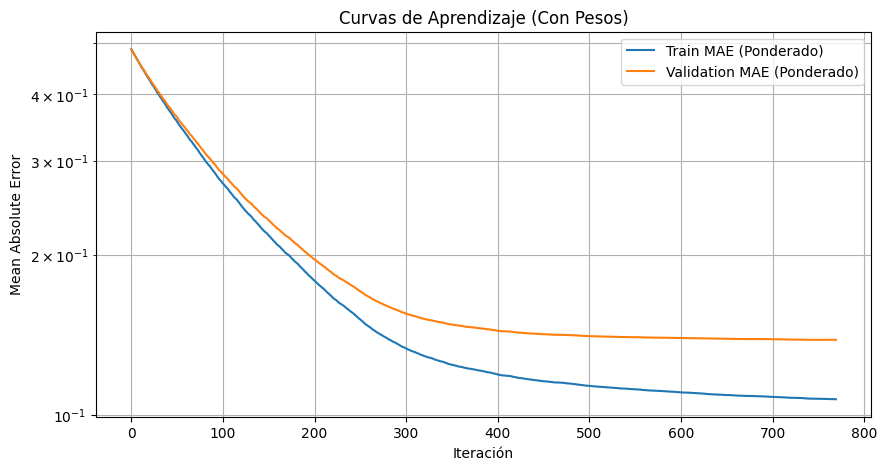

Modelo guardado con éxito.


In [3]:
import pandas as pd
import numpy as np
import xgboost as xgb
import optuna
import sklearn.metrics
import json
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# 1. PREPARACI\u00d3N DE DATOS (siempre, para tener X_val disponible aguas abajo)
df = pd.read_csv(DATASET_CSV)
features = ['log_fa', 'pq_qL', 'pq_lL', 'pq_uR', 'pq_dR', 'pq_eR']
X = df[features]
y = df['target']

# Pesos: excluidos y frontera (target <= 0.8) pesan x5
pesos = np.where(y <= 0.8, 5.0, 1.0)

X_train, X_val, y_train, y_val, w_train, w_val = train_test_split(
    X, y, pesos, test_size=0.2, random_state=42
)

dtrain = xgb.DMatrix(X_train.values, label=y_train, weight=w_train, feature_names=features)
dval   = xgb.DMatrix(X_val.values,   label=y_val,   weight=w_val,   feature_names=features)
evals = [(dtrain, 'train'), (dval, 'eval')]

# 2. ENTRENAMIENTO (gateado)
if not FORCE_RETRAIN and MODEL_PATH.exists():
    print(f"Modelo ya existe en {MODEL_PATH} \u2014 usando cach\u00e9. FORCE_RETRAIN=True para reentrenar.")
else:
    # 2a. Optuna
    def optuna_obj(trial):
        params = {
            'objective': 'reg:squarederror',
            'tree_method': 'hist',
            'max_depth': trial.suggest_int('max_depth', 2, 6),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1),
            'gamma': trial.suggest_float('gamma', 0.1, 5.0),
            'min_child_weight': trial.suggest_int('min_child_weight', 5, 20),
            'subsample': trial.suggest_float('subsample', 0.5, 0.9),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 0.9),
            'eval_metric': 'mae',
            'nthread': -1,
            'base_score': 0.5,
            'reg_alpha':  trial.suggest_float('reg_alpha',  0.1, 10.0),
            'reg_lambda': trial.suggest_float('reg_lambda', 0.1, 10.0),
        }
        model_clf = xgb.train(
            params, dtrain, num_boost_round=1000, evals=evals,
            early_stopping_rounds=20, verbose_eval=False,
        )
        predictions = model_clf.predict(dval)
        return sklearn.metrics.mean_absolute_error(y_val, predictions, sample_weight=w_val)

    print("Iniciando b\u00fasqueda de hiperpar\u00e1metros...")
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    study = optuna.create_study(direction='minimize')
    study.optimize(optuna_obj, n_trials=100, timeout=300, show_progress_bar=True)

    with open(BEST_PARAMS, 'w') as f:
        json.dump(study.best_params, f)

    # 2b. Entrenamiento final
    with open(BEST_PARAMS, 'r') as f:
        best_params = json.load(f)

    print(f"\nEntrenando con los mejores par\u00e1metros...")
    final_config = best_params | {
        'objective': 'reg:squarederror',
        'tree_method': 'hist',
        'eval_metric': ['mae'],
        'nthread': -1,
        'base_score': 0.5,
    }

    eval_results = {}
    model_final = xgb.train(
        final_config, dtrain, num_boost_round=1000, evals=evals,
        early_stopping_rounds=30, verbose_eval=False, evals_result=eval_results,
    )

    # 2c. Curva de aprendizaje
    plt.figure(figsize=(10, 5))
    plt.plot(eval_results['train']['mae'], label='Train MAE (Ponderado)')
    plt.plot(eval_results['eval']['mae'],  label='Validation MAE (Ponderado)')
    plt.yscale('log')
    plt.xlabel('Iteraci\u00f3n')
    plt.ylabel('Mean Absolute Error')
    plt.title('Curvas de Aprendizaje (Con Pesos)')
    plt.legend()
    plt.grid(True, which="both", ls="-")
    plt.savefig(FIGURES_DIR / "learning_curve_uv.png", dpi=150, bbox_inches='tight')
    plt.show()

    model_final.save_model(MODEL_PATH)
    print(f"Modelo guardado en {MODEL_PATH}")


## <a id="sec-4"></a>§4. Interpretabilidad SHAP

`shap.Explainer` con `model.predict` directo \u2014 dispara el **Permutation Explainer**,
que es rápido y evita los `TypeError`/`ValueError` que da el `TreeExplainer` al releer
el JSON de XGBoost. Cuatro vistas:

- **Beeswarm**: distribución de los valores SHAP por feature, color = valor del feature.
- **Bar**: importancia global media (|SHAP|).
- **Waterfall** del primer punto: cómo se construye la predicción individual.
- **Dependence (scatter)** por feature: efecto marginal y posibles interacciones.

> Nota: estos plots se muestran inline pero no se guardan automáticamente. Las versiones que están en `outputs/figures/SHAP*.png` son guardados manuales.


Modelo UV cargado correctamente.


ExactExplainer explainer: 15000it [28:56,  8.63it/s]                             


Generando Bee Swarm Plot...


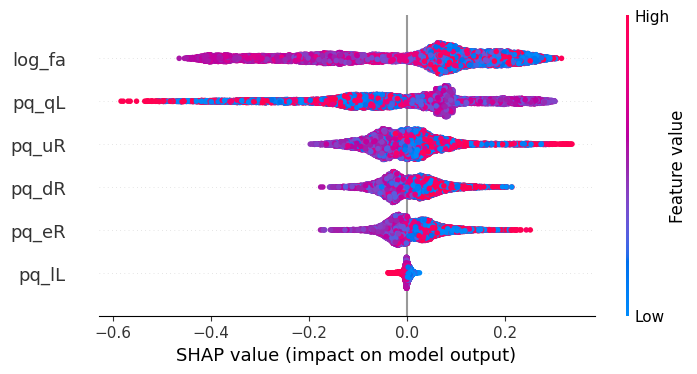

Generando Bar Plot...


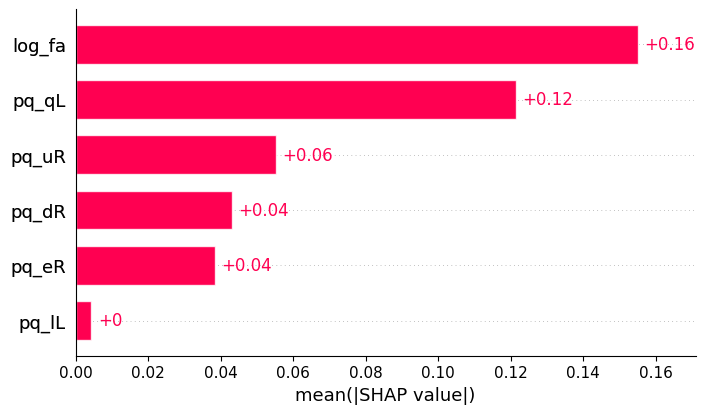

Generando Waterfall Plot...


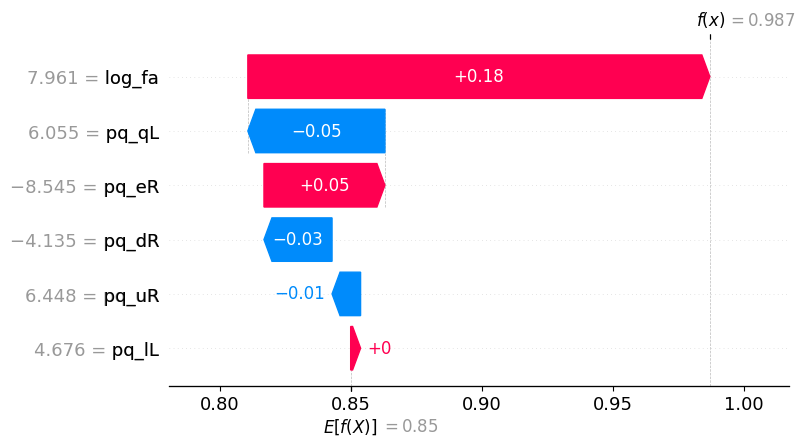

Generando Scatter Plots...


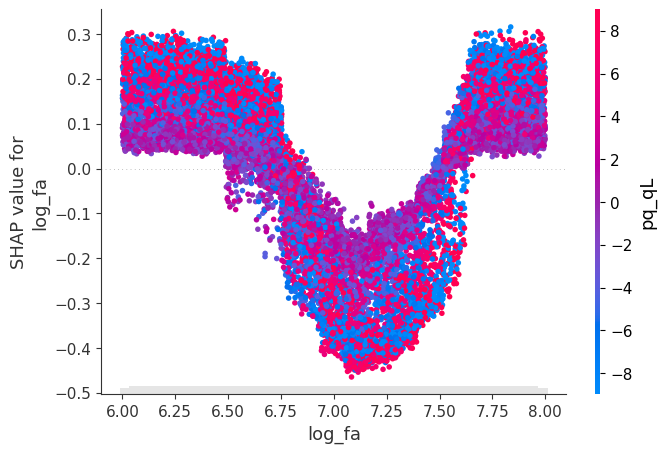

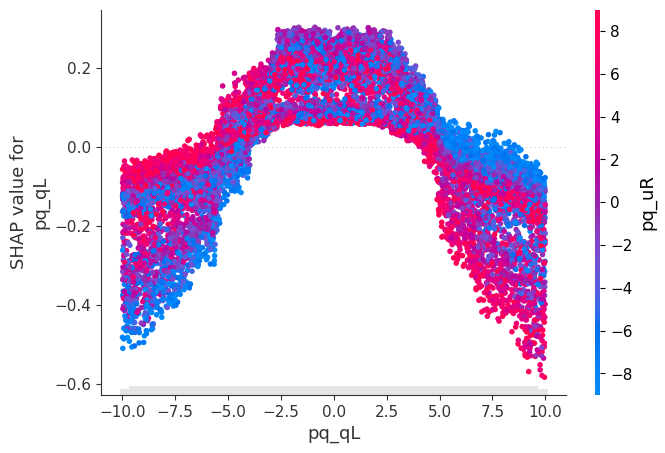

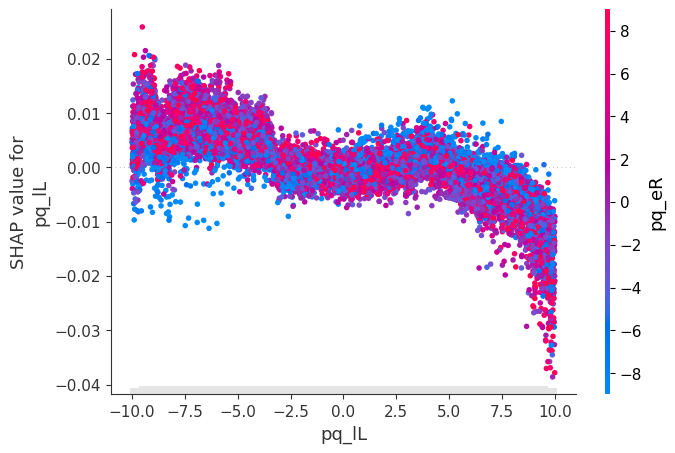

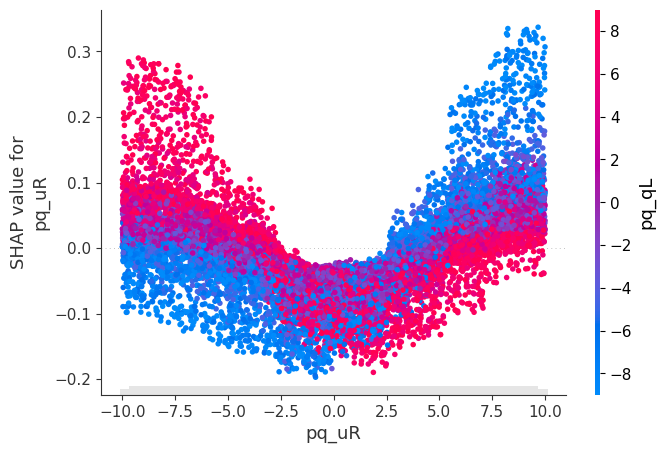

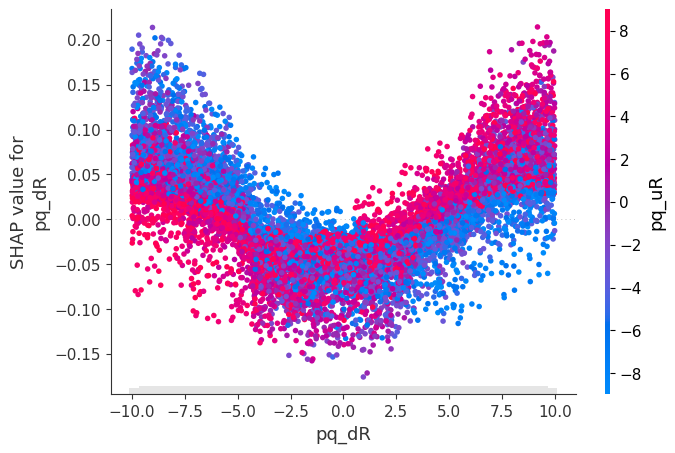

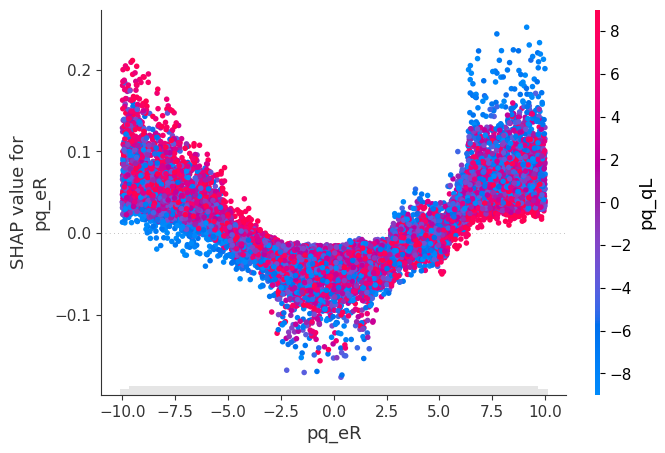

In [7]:
import pandas as pd
import xgboost as xgb
import shap
import matplotlib.pyplot as plt
import numpy as np

# 1. CARGAR DATOS Y MODELO
df = pd.read_csv(DATASET_CSV)
features = ['log_fa', 'pq_qL', 'pq_lL', 'pq_uR', 'pq_dR', 'pq_eR']
X = df[features]

model = xgb.XGBRegressor()
model.load_model(MODEL_PATH)
print("Modelo UV cargado correctamente.")

# 2. PERMUTATION EXPLAINER
explainer = shap.Explainer(model.predict, X)
shap_values = explainer(X)

# 3. SUMMARY (BEE SWARM)
print("Generando Bee Swarm Plot...")
plt.figure(figsize=(10, 6))
shap.plots.beeswarm(shap_values)

# 4. IMPORTANCIA GLOBAL (BAR)
print("Generando Bar Plot...")
plt.figure(figsize=(10, 6))
shap.plots.bar(shap_values)

# 5. WATERFALL (Punto 0)
print("Generando Waterfall Plot...")
shap.plots.waterfall(shap_values[0])

# 6. DEPENDENCE PLOTS
print("Generando Scatter Plots...")
for col in features:
    shap.plots.scatter(shap_values[:, col], color=shap_values)


## <a id="sec-5"></a>§5. Posterior MCMC + corner plot

`emcee.EnsembleSampler` (50 walkers × 5 000 pasos) sobre el surrogate XGBoost.

- **Prior**: uniforme en $\log f_a \in [6, 8]$ y cada $p^X \in [-5, 5]$ (más estrecho que los rangos del dataset, $[-10, 10]$, para enfocar la zona físicamente interesante).
- **Likelihood**: $\log L(\theta) = \log(\text{clip}(\hat{p}(\theta), 10^{-10}, 1))$, donde $\hat{p}$ es la salida del XGBoost (target sigmoide).
- **Burn-in**: 1 000 pasos descartados, thin = 15.
- **Output**: `outputs/figures/corner_plot_uv.png` y `outputs/datasets/posterior_samples_uv.csv`.


Iniciando muestreo MCMC para el modelo UV (ndim=6)...


100%|██████████| 5000/5000 [02:20<00:00, 35.51it/s]


Muestreo completado. Tamaño de la muestra final: 13300


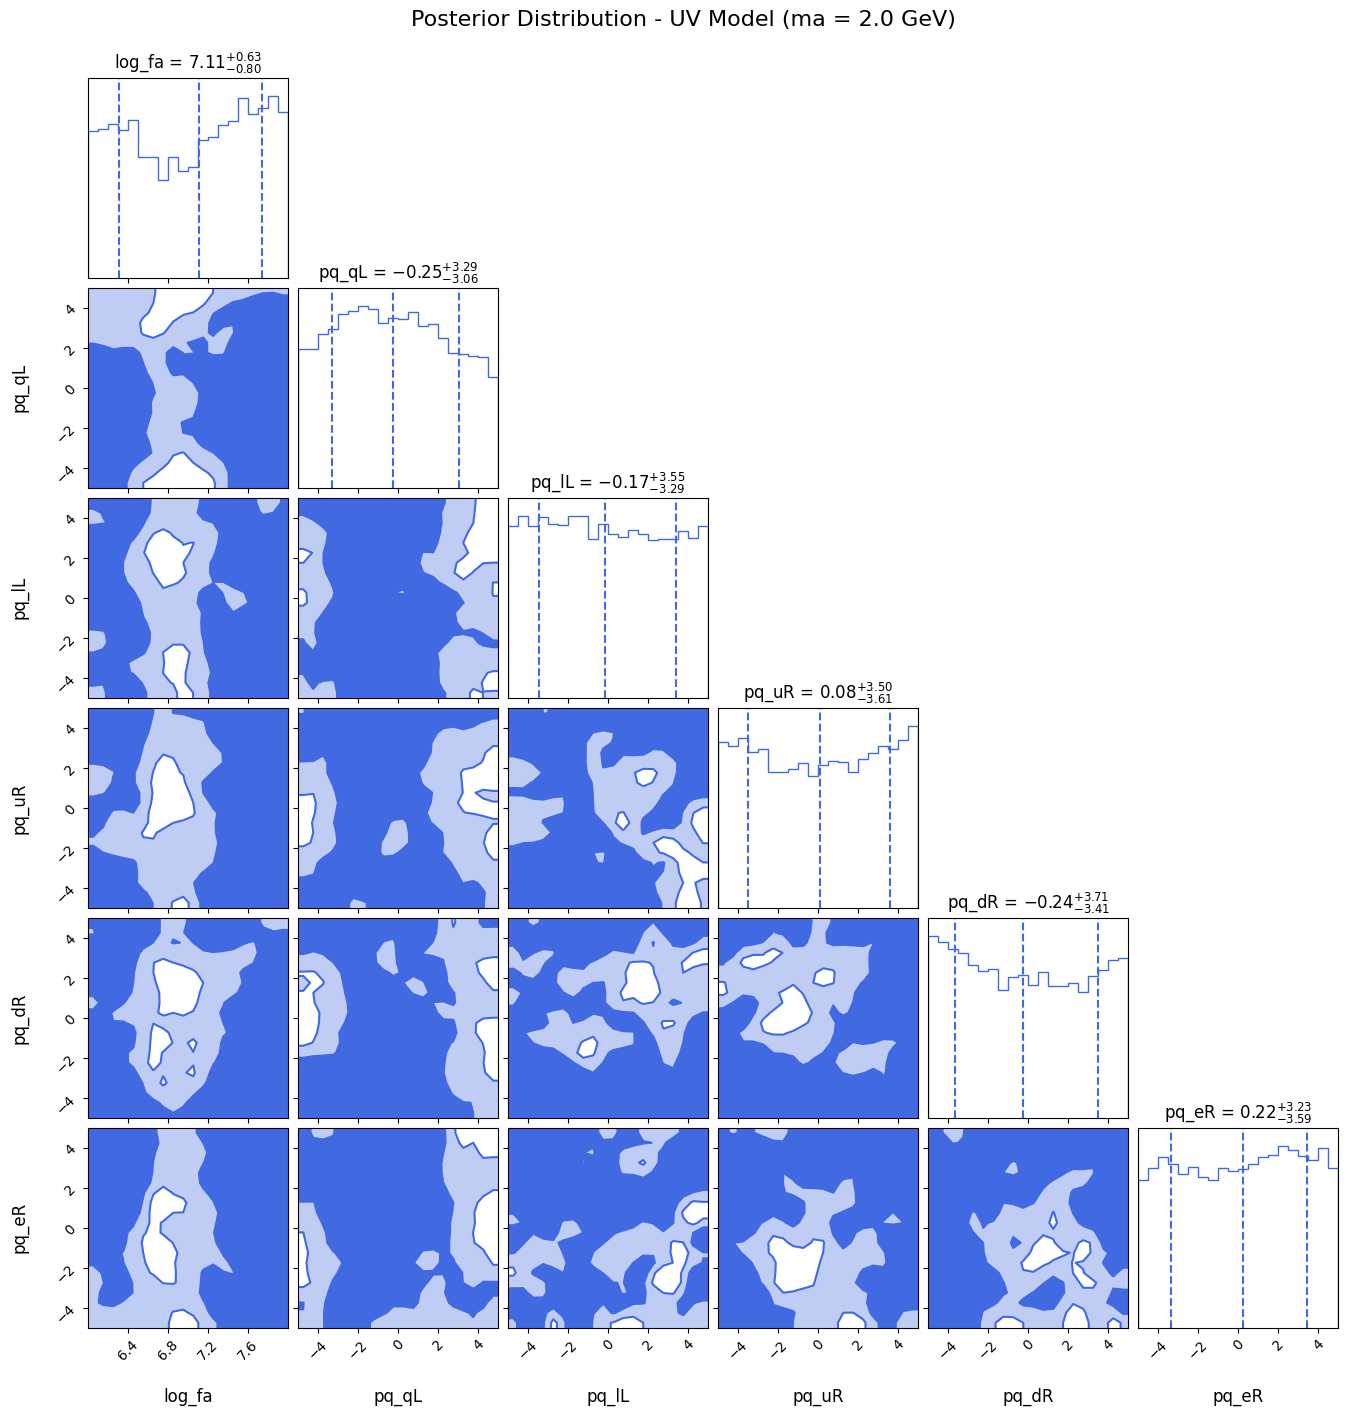

In [8]:
import numpy as np
import pandas as pd
import xgboost as xgb
import emcee
import corner
import matplotlib.pyplot as plt

# CARGAR EL MODELO ENTRENADO
model = xgb.XGBRegressor()
model.load_model(MODEL_PATH)

features = ['log_fa', 'pq_qL', 'pq_lL', 'pq_uR', 'pq_dR', 'pq_eR']

L_BOUNDS = np.array([6.0, -5.0, -5.0, -5.0, -5.0, -5.0])
U_BOUNDS = np.array([8.0,  5.0,  5.0,  5.0,  5.0,  5.0])

def log_prior(theta):
    if np.all((theta >= L_BOUNDS) & (theta <= U_BOUNDS)):
        return 0.0
    return -np.inf

def log_likelihood(theta):
    x = theta.reshape(1, -1)
    prob = model.predict(x)[0]
    prob = np.clip(prob, 1e-10, 1.0)
    return np.log(prob)

def log_probability(theta):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta)

# Configurar el sampler
ndim = 6
nwalkers = 50
nsteps = 5000

pos = L_BOUNDS + (U_BOUNDS - L_BOUNDS) * np.random.rand(nwalkers, ndim)
sampler = emcee.EnsembleSampler(nwalkers, ndim, log_probability)

print(f"Iniciando muestreo MCMC (ndim={ndim}, walkers={nwalkers}, steps={nsteps})...")
sampler.run_mcmc(pos, nsteps, progress=True)

# Burn-in 1000, thin 15
flat_samples = sampler.get_chain(discard=1000, thin=15, flat=True)
print(f"Muestreo completado. Muestras finales: {flat_samples.shape[0]}")

# Corner plot
corner_kwargs = {
    "labels": features,
    "show_titles": True,
    "title_fmt": ".2f",
    "quantiles": [0.16, 0.5, 0.84],
    "color": "royalblue",
    "smooth": 0.9,
    "levels": (0.68, 0.95),
    "fill_contours": True,
    "plot_datapoints": False,
    "label_kwargs": {"fontsize": 12},
    "title_kwargs": {"fontsize": 12},
}

fig = corner.corner(flat_samples, **corner_kwargs)
plt.suptitle(f"Posterior Distribution \u2014 UV Model (ma = 2.0 GeV)", fontsize=16, y=1.02)

plt.savefig(CORNER_PNG, dpi=300, bbox_inches='tight')
plt.show()

# Guardar muestras
samples_df = pd.DataFrame(flat_samples, columns=features)
samples_df.to_csv(POSTERIOR_CSV, index=False)
print(f"Posterior guardado en {POSTERIOR_CSV}")
